<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [4]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [ ]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [8]:
## Identifying and removing duplicate rows using drop_duplicates() method
duplicate_rows= df[df.duplicated()]
duplicate_rows

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat


In [9]:
#removing duplicate rows using drop_duplicates() method
df.drop_duplicates(inplace=True)

### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [10]:
## Identifying missing values in CodingActivities column using isna() method
missing_values = df['CodingActivities'].isna()
missing_values

,CodingActivities
0,False
1,False
2,False
3,True
4,True
...,...
65432,False
65433,False
65434,False
65435,False


##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [11]:
## Imputing missing values in CodingActivities with forward-fill (method=ffill)
df['CodingActivities'].fillna(method='ffill', inplace=True)

/tmp/ipython-input-801482618.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CodingActivities'].fillna(method='ffill', inplace=True)
/tmp/ipython-input-801482618.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['CodingActivities'].fillna(method='ffill', inplace=True)


**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [12]:
## Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately.
## We will look at the statistic description of the column
df['ConvertedCompYearly'].describe()

,ConvertedCompYearly
count,2.343500e+04
mean,8.615529e+04
std,1.867570e+05
min,1.000000e+00
25%,3.271200e+04
50%,6.500000e+04
75%,1.079715e+05
max,1.625660e+07


In [13]:
## The mean(average) salary is $86,155, which is significantly higher than the median ($65,000).This is a classic sign of a right-skewed distribution
## For skewed data like salaries, the **median is a much more reliable measure
## So we will replace the misssing values with median value
df['ConvertedCompYearly'].fillna(df['ConvertedCompYearly'].median(), inplace=True)

/tmp/ipython-input-2319824018.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ConvertedCompYearly'].fillna(df['ConvertedCompYearly'].median(), inplace=True)


##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [14]:
## We will apply the Min_Max normalization to the ConvertedCompYearly
df['ConvertedCompYearly_MinMax'] = (df['ConvertedCompYearly'] - df['ConvertedCompYearly'].min()) / (df['ConvertedCompYearly'].max() - df['ConvertedCompYearly'].min())

In [18]:
# Showing the normalized column values sorted in Descending order
df['ConvertedCompYearly_MinMax'].sort_values(ascending=False)

,ConvertedCompYearly_MinMax
15837,1.000000
12723,0.849994
28379,0.553621
17593,0.390030
17672,0.303678
...,...
10678,0.000000
40353,0.000000
22245,0.000000
24247,0.000000


##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [22]:
## Now, we will apply the Z-score Normalization to ConvertedCompYearly
df['ConvertedCompYearly_Zscore'] = (df['ConvertedCompYearly'] - df['ConvertedCompYearly'].mean()) / df['ConvertedCompYearly'].std()
df['ConvertedCompYearly_Zscore'].sort_values(ascending=False)

,ConvertedCompYearly_Zscore
15837,144.216079
12723,122.485851
28379,79.552392
17593,55.854122
17672,43.344966
...,...
10678,-0.646720
40353,-0.646720
22245,-0.646720
24247,-0.646720


### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, '')

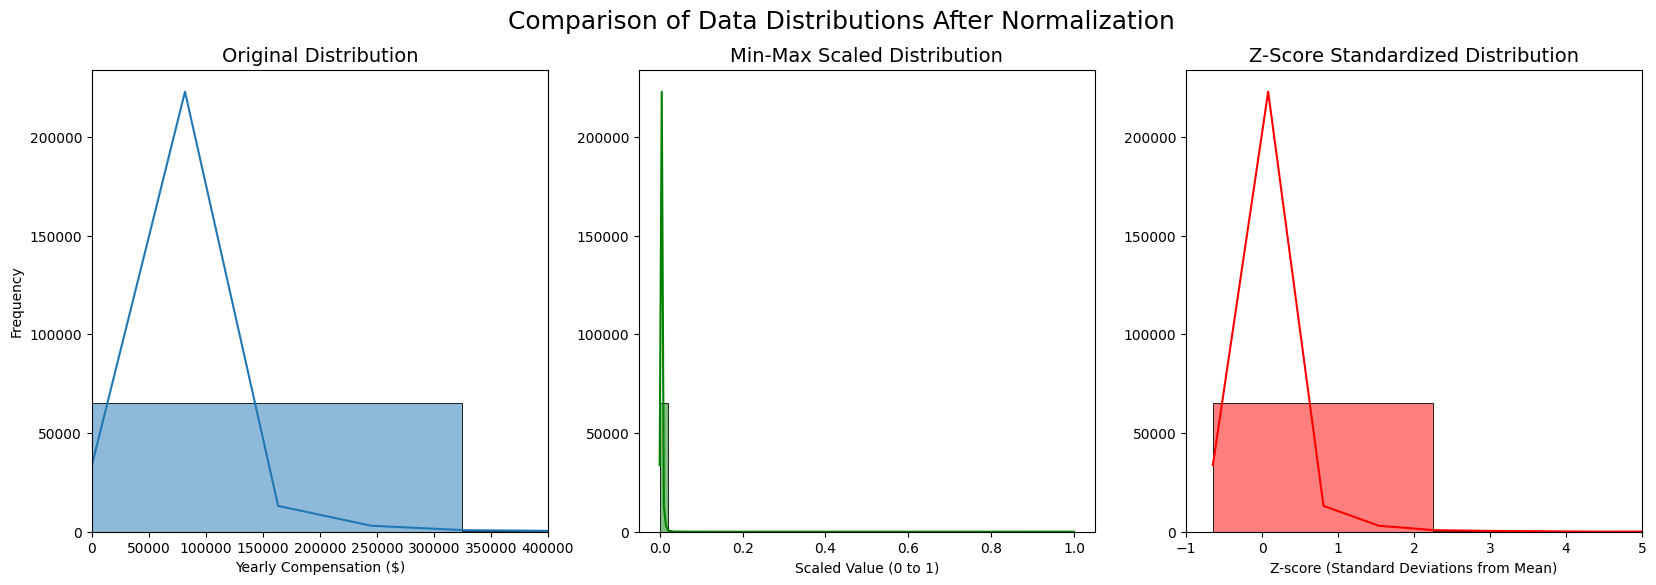

In [29]:
## Visualizing the distribution of ConvertedCompYearly, ConvertedCompYearly_MinMax, and ConvertedCompYearly_Zscore
## creating histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore).

# Set up the matplotlib figure with 3 subplots in a single row
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Comparison of Data Distributions After Normalization', fontsize=18)

# Plot 1: Original Data Distribution
# We'll filter the range to make the main distribution visible, as outliers squash the view.
sns.histplot(df['ConvertedCompYearly'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Original Distribution', fontsize=14)
axes[0].set_xlabel('Yearly Compensation ($)')
axes[0].set_xlim(0, 400000) # Limiting x-axis to see the bulk of the data
axes[0].set_ylabel('Frequency')

# Plot 2: Min-Max Scaled Distribution
sns.histplot(df['ConvertedCompYearly_MinMax'], bins=50, ax=axes[1], kde=True, color='green')
axes[1].set_title('Min-Max Scaled Distribution', fontsize=14)
axes[1].set_xlabel('Scaled Value (0 to 1)')
axes[1].set_ylabel('') # Hide y-label for clarity



# Plot 3: Z-Score Standardized Distribution
sns.histplot(df['ConvertedCompYearly_Zscore'], bins=50, ax=axes[2], kde=True, color='red')
axes[2].set_title('Z-Score Standardized Distribution', fontsize=14)
axes[2].set_xlabel('Z-score (Standard Deviations from Mean)')
axes[2].set_xlim(-1, 5) # Limiting x-axis to see the bulk of the data
axes[2].set_ylabel('') # Hide y-label for clarity

### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
